In [11]:
import torch
import torch.nn as nn
from constants import LABELS
from my_dataset import MyDataset as DS
from model_manager import ModelManager as Manager
from model_manager import MyNN

class AttentionModelBody(nn.Module):
    def __init__(self, input_dim=1344, embed_dim=256, num_heads=8, num_classes=10):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, embed_dim)  # Project input to embed_dim
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        
        # Feedforward layers after attention
        self.ff = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        # x shape: (batch_size, 1344)
        
        # Project input
        x = self.input_proj(x)  # (batch_size, embed_dim)
        x = x.unsqueeze(1)  # (batch, seq_len=1, embed_dim)
    
        attn_output, attn_weights = self.attention(x, x, x)
        
        # Remove sequence dim for feedforward
        attn_output = attn_output.squeeze(1)  # (batch, embed_dim)
        
        out = self.ff(attn_output)  # (batch, num_classes)
        return out

class ChunkedAttentionModelBody(nn.Module):
    def __init__(self, input_dim=1344, chunk_size=32, num_heads=4, num_classes=10):
        super().__init__()
        self.seq_len = input_dim // chunk_size  # 42
        self.embed_dim = chunk_size  # 32

        self.attention = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=num_heads, batch_first=True)
        self.ff = nn.Sequential(
            # nn.LayerNorm(self.embed_dim),
            nn.Linear(self.embed_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, self.seq_len, self.embed_dim)  # (batch, seq_len=42, embed_dim=32)
        
        attn_output, _ = self.attention(x, x, x)  # same shape output (batch, seq_len, embed_dim)
        
        # Pool across sequence dimension (mean or max)
        pooled = attn_output.mean(dim=1)  # (batch, embed_dim)
        
        out = self.ff(pooled)
        return out

train_filepaths = ["standard1/train.csv", "augment_class3_4times_with_time_mixup/train.csv",  "augment_class3_10times_with_time_mixup/train.csv"]
test_filepaths = ["standard1/test.csv"]
train_loader = DS.get_loader(train_filepaths, shuffle=True, batch_size=64, num_workers=63)
test_loader = DS.get_loader(test_filepaths, batch_size=64, num_workers=63)

num_classes = len(LABELS) #9
num_features = train_loader.dataset.datasets[0].num_features
model_class = MyNN
model_body = ChunkedAttentionModelBody(input_dim=1344, chunk_size=32, num_heads=4, num_classes=num_classes)
loss_fn = nn.CrossEntropyLoss()

print("done")


done


/usr/local/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name       | Type                      | Params | Mode 
-----------------------------------------------------------------
0 | model_body | ChunkedAttentionModelBody | 87.9 K | train
1 | loss_fn    | CrossEntropyLoss          | 0      | train
-----------------------------------------------------------------
87.9 K    Trainable params
0         Non-trainable params
87.9 K    Total params
0.352     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


Train Time (s): 109.60404229164124


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7472693920135498     │
│         test_loss         │    0.7023745179176331     │
└───────────────────────────┴───────────────────────────┘

Test Time (s): 1.7891349792480469


<Figure size 1600x1600 with 0 Axes>

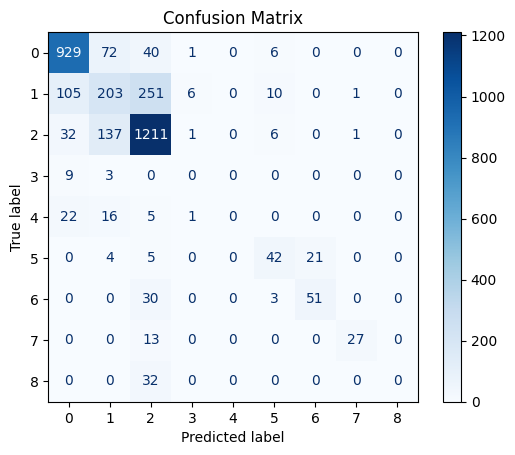

Logger Metics:  logs/experiment_attentionbody1/version_5/metrics.csv


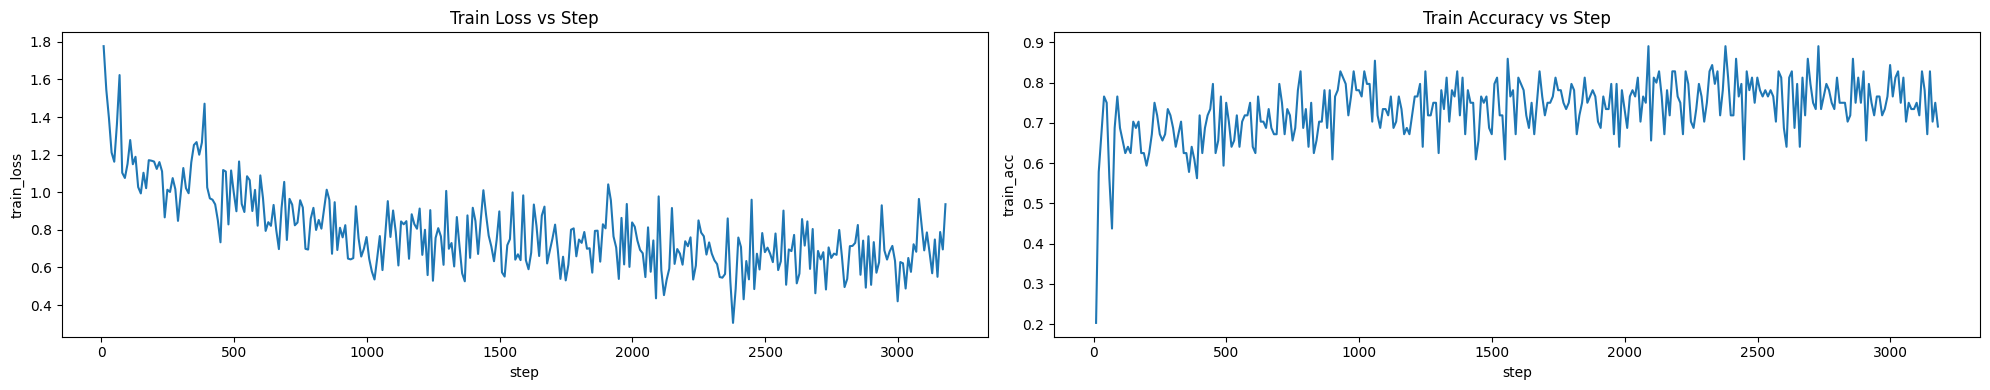

done


In [12]:
model_name = "experiment_attentionbody1" #### REMEMBER TO CHANGE THE NAME
max_epochs = 15
manager = Manager(model_name, max_epochs, model_class, model_body, loss_fn)
manager.train(train_loader)
manager.test(test_loader)
manager.confustion_matrix(test_loader, num_classes)
manager.plot_logger()
print("done")